# ST-GNN Model Results

Visualizza i risultati del modello salvato da `python main.py`.

> **Pre-requisito**: eseguire `python main.py` dalla root del progetto.

In [1]:
import sys, json, os
from pathlib import Path
sys.path.insert(0, str(Path('..').resolve()))

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import xarray as xr

from main import _normalize_dataset
from physiq_pv.model.st_gnn import STGNN
from physiq_pv.model.graph_builder import build_graph
from physiq_pv.data.dataset import PVDataset
from physiq_pv.data.quality_score import compute_qs, apply_qs_shrinkage
from physiq_pv.data.load_kwp import load_kwp
from physiq_pv.data.sentinel_hourly_loader import load_sentinel_hourly, merge_with_weather
from torch.utils.data import DataLoader

sns.set_theme(style='darkgrid')
CKPT = '../checkpoints'

with open(f'{CKPT}/model_config.json') as f:
    cfg = json.load(f)
with open(f'{CKPT}/loss_history.json') as f:
    _lh = json.load(f)
loss_history     = _lh['train'] if isinstance(_lh, dict) else _lh
val_loss_history = _lh.get('val', []) if isinstance(_lh, dict) else []

calib_path = f'{CKPT}/pv_calibration.json'
pv_calibration = {
    'enabled': False,
    'slope': 1.0,
    'intercept': 0.0,
    'daytime_ghi_threshold': 0.01,
}
if os.path.exists(calib_path):
    with open(calib_path) as f:
        pv_calibration = json.load(f)
    if pv_calibration.get('enabled', False):
        print(
            f"PV calibration loaded: slope={pv_calibration['slope']:.4f}, "
            f"intercept={pv_calibration['intercept']:+.4f}, "
            f"day_threshold={pv_calibration.get('daytime_ghi_threshold', 0.01):.3f}"
        )

MODEL_CFG_KEYS = {
    'n_nodes', 'n_features', 'seq_len', 'patch_len', 'stride',
    'd_model', 'gat_dim', 'gat_heads', 'gat_layers', 'dropout'
}
model_cfg = {k: cfg[k] for k in MODEL_CFG_KEYS if k in cfg}
model = STGNN(**model_cfg)
model.load_state_dict(torch.load(f'{CKPT}/model.pt', map_location='cpu'))
model.eval()
print(f'Model: {sum(p.numel() for p in model.parameters()):,} params')
print(f'Train loss: {[round(l, 4) for l in loss_history]}')
if val_loss_history:
    print(f'Val   loss: {[round(l, 4) for l in val_loss_history]}')
    print(f'Best val:   {min(val_loss_history):.4f} @ epoch {val_loss_history.index(min(val_loss_history))+1}')

# Load Sentinel hourly data (1116 plants, 5743 hours, 2019-03 to 2019-12)
print('\nLoading Sentinel hourly data...')
ds = load_sentinel_hourly(
    sentinel_dir='/data/SentinelPV/energy_data/piemonte_energy_data/single_ups',
    year=2019,
    plant_mapping_path='../data/plant_mapping.csv',
    energy_coords_path='../data/energy_with_coordinates.csv',
)
ds = merge_with_weather(ds, pvgis_path='../data/piedmont_pvgis_2019.nc')
ds = _normalize_dataset(ds)
qs_raw, m_components = compute_qs(ds, debug=True)
qs = apply_qs_shrinkage(qs_raw, ds, asymmetric=False)
print(f'QS shrinkage applied: prior={qs.attrs["qs_prior"]:.3f}, n0={qs.attrs["shrinkage_n0"]}, scale={qs.attrs["shrinkage_scale"]}')
edge_index, edge_weight = build_graph(ds['lat'].values, ds['lon'].values, max_dist_km=20.0)
print(f'Graph: {ds.sizes["plant"]} nodes, {edge_index.shape[1]} edges')

kwp = None
if os.path.exists('../data/plant_mapping.csv') and os.path.exists('../data/energy_with_coordinates.csv'):
    kwp = load_kwp('../data/plant_mapping.csv', '../data/energy_with_coordinates.csv', ds.sizes['plant'])
    print(f'Real kWp loaded: {int(np.sum(np.isfinite(kwp)))}/{ds.sizes["plant"]} plants  range=[{np.nanmin(kwp):.0f}, {np.nanmax(kwp):.0f}] kW')

dataset = PVDataset(ds, m_components, kwp=kwp)
loader  = DataLoader(dataset, batch_size=64, shuffle=False)
print(f'Dataset: {len(dataset)} samples  ({ds.sizes["plant"]} plants x {ds.sizes["time"]} hours)')

/home/apedalino/physiq_pv/physiq_pv/model/patchtst_encoder.py:54: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)


Model: 187,155 params
Train loss: [0.0796, 0.0322, 0.0306, 0.0292, 0.0282, 0.027, 0.027, 0.0259, 0.0253, 0.0253]
Val   loss: [0.0338, 0.0403, 0.0314, 0.0299, 0.0275, 0.0274, 0.0271, 0.0256, 0.0253, 0.0281]
Best val:   0.0253 @ epoch 9

Loading Sentinel hourly data...
  Found 1116 Sentinel files for year 2019
  Loading 1116 UPN plants...
  Unique timestamps across all plants: 5743
  Stacked: 1116 plants x 5743 timesteps (aligned to common time grid)
  Dataset: 1116 plants x 5743 hours
  Matching 1116 plants to PVGIS grid (1149 locations)...
  Time alignment: Sentinel 5743 hours, PVGIS 8760 hours
  Merged weather variables: temperature_2m, solar_irradiance_poa, wind_speed_10m
QS shrinkage applied: prior=0.783, n0=381.25158450565203, scale=101.2145602966849
Graph: 1116 nodes, 113312 edges
Real kWp loaded: 94/1116 plants  range=[3, 4997] kW
Dataset: 5718 samples  (1116 plants x 5743 hours)


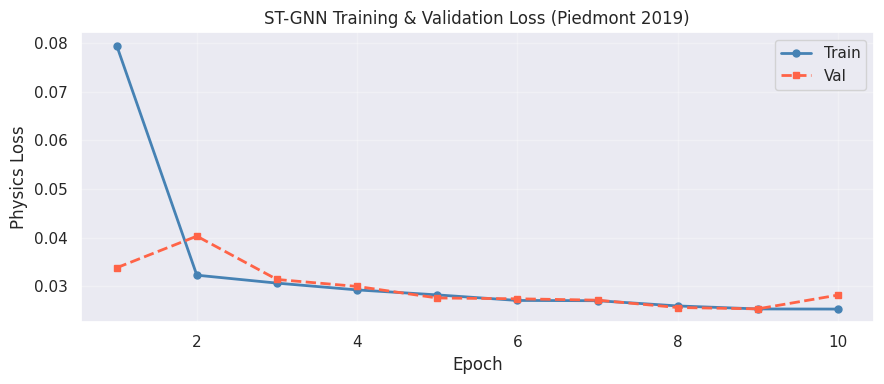

=== LOSS CURVE ===
  Epoch  1: train=0.0796  val=0.0338
  Epoch  2: train=0.0322  val=0.0403  (+59.5%)
  Epoch  3: train=0.0306  val=0.0314  (+5.1%)
  Epoch  4: train=0.0292  val=0.0299  (+4.6%)
  Epoch  5: train=0.0282  val=0.0275  (+3.5%)
  Epoch  6: train=0.0270  val=0.0274  (+4.1%)
  Epoch  7: train=0.0270  val=0.0271  (+0.2%)
  Epoch  8: train=0.0259  val=0.0256  (+4.0%)
  Epoch  9: train=0.0253  val=0.0253  (+2.4%)
  Epoch 10: train=0.0253  val=0.0281  (+0.1%)
  Total drop: 68.2%
  Best val epoch: 9  val=0.0253


In [2]:
# Loss curve
fig, ax = plt.subplots(figsize=(9, 4))
epochs = range(1, len(loss_history) + 1)
ax.plot(epochs, loss_history, 'o-', color='steelblue', linewidth=2, markersize=5, label='Train')
if val_loss_history:
    ax.plot(range(1, len(val_loss_history) + 1), val_loss_history, 's--', color='tomato', linewidth=2, markersize=5, label='Val')
ax.set_xlabel('Epoch')
ax.set_ylabel('Physics Loss')
ax.set_title('ST-GNN Training & Validation Loss (Piedmont 2019)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("=== LOSS CURVE ===")
for i, v in enumerate(loss_history):
    drop = f"  ({(loss_history[i-1]-v)/loss_history[i-1]*100:+.1f}%)" if i > 0 else ""
    val_str = f"  val={val_loss_history[i]:.4f}" if i < len(val_loss_history) else ""
    print(f"  Epoch {i+1:>2}: train={v:.4f}{val_str}{drop}")
total_drop = (loss_history[0] - loss_history[-1]) / loss_history[0] * 100
print(f"  Total drop: {total_drop:.1f}%")
if val_loss_history:
    best_ep = val_loss_history.index(min(val_loss_history)) + 1
    print(f"  Best val epoch: {best_ep}  val={min(val_loss_history):.4f}")

Inference on: cuda


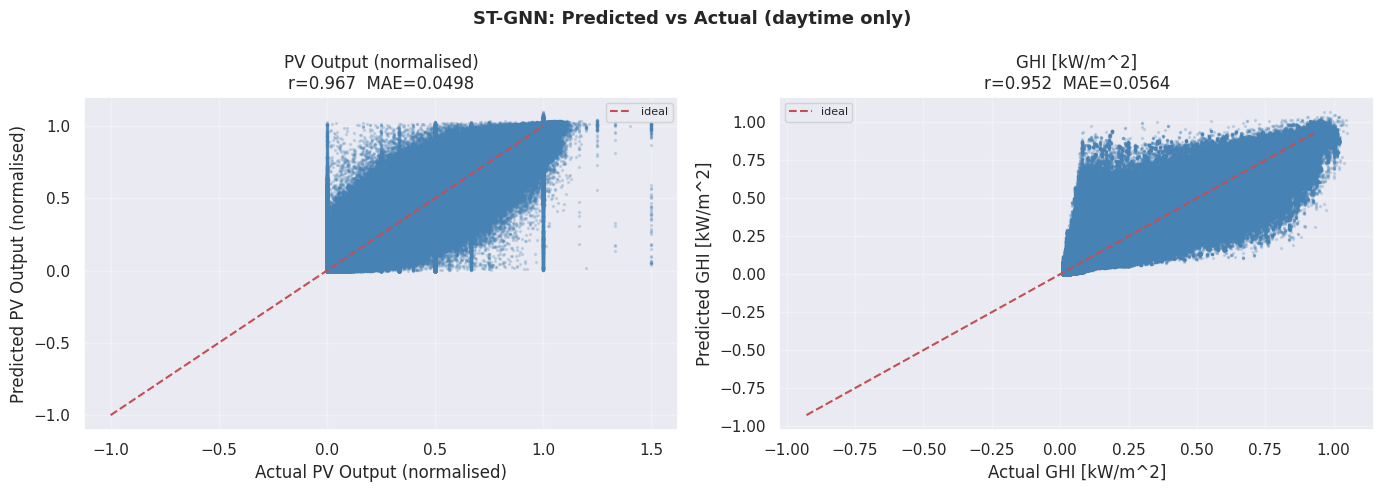


=== SCATTER METRICS (daytime, n=3,061,186) ===
  PV Output (normalised):
    r=0.967  MAE=0.0498  RMSE=0.0842  bias=+0.0048
    actual  range: [0.000, 1.500]  mean=0.366
    predicted range: [0.000, 1.096]  mean=0.371
    negative predictions: 0 (0.0%)
  GHI [kW/m^2]:
    r=0.952  MAE=0.0564  RMSE=0.0830  bias=-0.0111
    actual  range: [0.011, 1.049]  mean=0.342
    predicted range: [0.000, 1.066]  mean=0.331
    negative predictions: 0 (0.0%)

=== PV ERROR BY QS BIN (daytime, n=3,061,186) ===
  low      (<p5=0.713): n=  153,060  QS_mean=0.635  MAE=0.0658  RMSE=0.1201  bias=+0.0076  actual_mean=0.457  pred_mean=0.464
  mid-low  (0.713-0.761): n=  612,236  QS_mean=0.747  MAE=0.0564  RMSE=0.0935  bias=+0.0086  actual_mean=0.352  pred_mean=0.361
  medium   (0.761-0.783): n=1,073,453  QS_mean=0.771  MAE=0.0473  RMSE=0.0768  bias=+0.0042  actual_mean=0.378  pred_mean=0.383
  high     (0.783-0.796): n=1,069,377  QS_mean=0.785  MAE=0.0466  RMSE=0.0807  bias=+0.0028  actual_mean=0.332  pred_

In [3]:
# Inference: collect pred vs actual
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
model.to(DEVICE)
ei = edge_index.to(DEVICE)
ew = edge_weight.to(DEVICE)
print(f'Inference on: {DEVICE}')

if 'pv_calibration' not in globals():
    pv_calibration = {'enabled': False, 'slope': 1.0, 'intercept': 0.0, 'daytime_ghi_threshold': 0.01}

daytime_ghi_threshold = float(pv_calibration.get('daytime_ghi_threshold', 0.01))
calib_enabled = bool(pv_calibration.get('enabled', False))
calib_slope = float(pv_calibration.get('slope', 1.0))
calib_intercept = float(pv_calibration.get('intercept', 0.0))

all_pred_pv, all_true_pv = [], []
all_pred_ghi, all_true_ghi = [], []
all_time_idx = []
all_plant_id = []

with torch.no_grad():
    for i, (x, y_ghi, y_pv, eta, ghi_cs) in enumerate(loader):
        if i >= 200:
            break
        pg, pp = model(x.to(DEVICE), ei, ew, ghi_cs.to(DEVICE))
        pp_np = pp.cpu().numpy()
        if calib_enabled:
            pp_np = calib_slope * pp_np + calib_intercept
        pp_np = np.clip(pp_np, 0.0, None)  # softplus >= 0; calibration can push small values negative
        all_pred_pv.append(pp_np)
        all_true_pv.append(y_pv.numpy())
        all_pred_ghi.append(pg.cpu().numpy())
        all_true_ghi.append(y_ghi.numpy())

        bsz, n_plants = y_pv.shape
        sample_idx = np.arange(i * loader.batch_size, i * loader.batch_size + bsz)
        target_time_idx = dataset.valid_starts[sample_idx]
        all_time_idx.append(np.repeat(target_time_idx, n_plants))
        all_plant_id.append(np.tile(np.arange(n_plants), bsz))

pred_pv  = np.concatenate(all_pred_pv).ravel()
true_pv  = np.concatenate(all_true_pv).ravel()
pred_ghi = np.concatenate(all_pred_ghi).ravel()
true_ghi = np.concatenate(all_true_ghi).ravel()
time_idx_flat = np.concatenate(all_time_idx)
plant_id_flat = np.concatenate(all_plant_id)

# Derive QS scalar at target step from the precomputed DataArray.
qs_arr_full = np.asarray(qs.values)  # (N_plants, T)
qs_flat = np.nan_to_num(qs_arr_full[plant_id_flat, time_idx_flat], nan=0.0)

day_mask   = true_ghi > daytime_ghi_threshold
pred_pv_d, true_pv_d   = pred_pv[day_mask],  true_pv[day_mask]
pred_ghi_d, true_ghi_d = pred_ghi[day_mask], true_ghi[day_mask]
qs_d = qs_flat[day_mask]
time_idx_d = time_idx_flat[day_mask]
plant_id_d = plant_id_flat[day_mask]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (p, t, label) in zip(axes, [
    (pred_pv_d,  true_pv_d,  'PV Output (normalised)'),
    (pred_ghi_d, true_ghi_d, 'GHI [kW/m^2]'),
]):
    lim = max(np.percentile(np.abs(t), 99), np.percentile(np.abs(p), 99))
    ax.scatter(t, p, s=2, alpha=0.2, color='steelblue')
    ax.plot([-lim, lim], [-lim, lim], 'r--', linewidth=1.5, label='ideal')
    corr = float(np.corrcoef(t, p)[0, 1])
    mae  = float(np.mean(np.abs(t - p)))
    ax.set_xlabel(f'Actual {label}')
    ax.set_ylabel(f'Predicted {label}')
    ax.set_title(f'{label}\nr={corr:.3f}  MAE={mae:.4f}')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle('ST-GNN: Predicted vs Actual (daytime only)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

def _metrics(p, t, name):
    corr  = float(np.corrcoef(t, p)[0, 1])
    mae   = float(np.mean(np.abs(t - p)))
    rmse  = float(np.sqrt(np.mean((t - p)**2)))
    bias  = float(np.mean(p - t))
    neg   = int((p < 0).sum())
    print(f"  {name}:")
    print(f"    r={corr:.3f}  MAE={mae:.4f}  RMSE={rmse:.4f}  bias={bias:+.4f}")
    print(f"    actual  range: [{t.min():.3f}, {t.max():.3f}]  mean={t.mean():.3f}")
    print(f"    predicted range: [{p.min():.3f}, {p.max():.3f}]  mean={p.mean():.3f}")
    print(f"    negative predictions: {neg} ({neg/len(p)*100:.1f}%)")

print(f"\n=== SCATTER METRICS (daytime, n={day_mask.sum():,}) ===")
_metrics(pred_pv_d,  true_pv_d,  "PV Output (normalised)")
_metrics(pred_ghi_d, true_ghi_d, "GHI [kW/m^2]")

def _metrics_by_qs_bin(pred, true, qs_values):
    valid = np.isfinite(pred) & np.isfinite(true) & np.isfinite(qs_values)
    pred = pred[valid]
    true = true[valid]
    qs_values = qs_values[valid]

    # Quantile-based bins (data-driven). Edges from observed QS distribution.
    qs_finite = qs_values[np.isfinite(qs_values)]
    q5, q25, q75, q95 = np.percentile(qs_finite, [5, 25, 75, 95])
    bins = [
        (-np.inf, q5,  f"low      (<p5={q5:.3f})"),
        (q5,  q25,     f"mid-low  ({q5:.3f}-{q25:.3f})"),
        (q25, q75,     f"medium   ({q25:.3f}-{q75:.3f})"),
        (q75, q95,     f"high     ({q75:.3f}-{q95:.3f})"),
        (q95, np.inf,  f"very high (>p95={q95:.3f})"),
    ]

    rows = []
    print(f"\n=== PV ERROR BY QS BIN (daytime, n={len(qs_values):,}) ===")
    for lo, hi, label in bins:
        mask = (qs_values >= lo) & (qs_values < hi)
        n = int(mask.sum())
        if n == 0:
            print(f"  {label:18s}: n=0")
            continue

        err = pred[mask] - true[mask]
        mae = float(np.mean(np.abs(err)))
        rmse = float(np.sqrt(np.mean(err ** 2)))
        bias = float(np.mean(err))
        q_mean = float(np.mean(qs_values[mask]))
        true_mean = float(np.mean(true[mask]))
        pred_mean = float(np.mean(pred[mask]))
        rows.append({
            "label": label,
            "n": n,
            "q_mean": q_mean,
            "mae": mae,
            "rmse": rmse,
            "bias": bias,
            "true_mean": true_mean,
            "pred_mean": pred_mean,
        })
        print(
            f"  {label:18s}: n={n:>9,}  QS_mean={q_mean:.3f}  "
            f"MAE={mae:.4f}  RMSE={rmse:.4f}  bias={bias:+.4f}  "
            f"actual_mean={true_mean:.3f}  pred_mean={pred_mean:.3f}"
        )

    if len(rows) >= 2:
        qs_means = np.array([r["q_mean"] for r in rows], dtype=float)
        maes = np.array([r["mae"] for r in rows], dtype=float)
        corr = float(np.corrcoef(qs_means, maes)[0, 1])
        print(f"  QS_mean vs MAE correlation across bins: {corr:+.3f} (expected negative)")

        if rows[-1]["mae"] < rows[0]["mae"]:
            print("  Interpretation: QS is aligned with predictive reliability (higher QS -> lower MAE).")
        else:
            print("  Interpretation: QS is not monotonic here; inspect bin composition and daytime mask.")

    return rows

qs_bin_rows = _metrics_by_qs_bin(pred_pv_d, true_pv_d, qs_d)


def _print_midlow_qs_diagnostics(pred, true, ghi, qs_values, plant_ids, time_indices):
    import pandas as pd

    valid = (
        np.isfinite(pred) & np.isfinite(true) & np.isfinite(ghi) &
        np.isfinite(qs_values) & np.isfinite(plant_ids) & np.isfinite(time_indices)
    )
    pred = pred[valid]
    true = true[valid]
    ghi = ghi[valid]
    qs_values = qs_values[valid]
    plant_ids = plant_ids[valid].astype(int)
    time_indices = time_indices[valid].astype(int)

    qs_finite_for_bin = qs_values[np.isfinite(qs_values)]
    _q5, _q25 = np.percentile(qs_finite_for_bin, [5, 25])
    mid = (qs_values >= _q5) & (qs_values < _q25)
    if int(mid.sum()) == 0:
        print("\n=== MID-LOW QS DIAGNOSTICS ===")
        print("  No samples in QS range [0.3, 0.5).")
        return None

    times_pd = pd.DatetimeIndex(ds.coords['time'].values)
    mid_times = times_pd[time_indices[mid]]
    err = pred - true

    print(f"\n=== MID-LOW QS DIAGNOSTICS (quantile-based, p5 <= QS < p25, daytime) ===")
    print(f"  n={int(mid.sum()):,} ({mid.mean()*100:.2f}% of daytime evaluated samples)")
    print(f"  MAE={np.mean(np.abs(err[mid])):.4f}  RMSE={np.sqrt(np.mean(err[mid]**2)):.4f}  bias={np.mean(err[mid]):+.4f}")
    print(f"  actual_mean={np.mean(true[mid]):.3f}  pred_mean={np.mean(pred[mid]):.3f}  ghi_mean={np.mean(ghi[mid]):.3f}  qs_mean={np.mean(qs_values[mid]):.3f}")

    # Top plants by number of mid-low samples.
    top_rows = []
    unique_plants, counts = np.unique(plant_ids[mid], return_counts=True)
    top_order = np.argsort(counts)[::-1][:20]
    qs_arr = qs.values  # (plant, time)
    daytime_full = ds['solar_irradiance_poa'].values / 1000.0 > daytime_ghi_threshold
    for p, n in zip(unique_plants[top_order], counts[top_order]):
        m = mid & (plant_ids == p)
        p_day_qs = qs_arr[p][daytime_full[p]]
        p_day_qs = p_day_qs[np.isfinite(p_day_qs)]
        top_rows.append({
            'plant': int(p),
            'n_midlow': int(n),
            'share_midlow_%': float(n / mid.sum() * 100.0),
            'plant_day_qs_mean': float(np.mean(p_day_qs)) if len(p_day_qs) else np.nan,
            'mae': float(np.mean(np.abs(err[m]))),
            'rmse': float(np.sqrt(np.mean(err[m] ** 2))),
            'bias': float(np.mean(err[m])),
            'actual_mean': float(np.mean(true[m])),
            'pred_mean': float(np.mean(pred[m])),
            'ghi_mean': float(np.mean(ghi[m])),
        })
    top_df = pd.DataFrame(top_rows)
    print("\n  Top plants contributing to mid-low bin:")
    print(top_df.to_string(index=False, formatters={
        'share_midlow_%': '{:.2f}'.format,
        'plant_day_qs_mean': '{:.3f}'.format,
        'mae': '{:.4f}'.format,
        'rmse': '{:.4f}'.format,
        'bias': '{:+.4f}'.format,
        'actual_mean': '{:.3f}'.format,
        'pred_mean': '{:.3f}'.format,
        'ghi_mean': '{:.3f}'.format,
    }))

    def _group_summary(values, labels, title):
        values = np.asarray(values)
        mid_idx = np.where(mid)[0]
        rows = []
        for lab in labels:
            if len(values) == len(mid):
                m_idx = np.where(mid & (values == lab))[0]
            elif len(values) == len(mid_idx):
                m_idx = mid_idx[values == lab]
            else:
                raise ValueError(f"{title}: values length {len(values)} is incompatible with full length {len(mid)} and mid length {len(mid_idx)}")
            if len(m_idx) == 0:
                continue
            rows.append({
                'group': lab,
                'n': int(len(m_idx)),
                'mae': float(np.mean(np.abs(err[m_idx]))),
                'bias': float(np.mean(err[m_idx])),
                'actual_mean': float(np.mean(true[m_idx])),
                'pred_mean': float(np.mean(pred[m_idx])),
                'ghi_mean': float(np.mean(ghi[m_idx])),
            })
        df = pd.DataFrame(rows)
        print(f"\n  {title}:")
        print(df.to_string(index=False, formatters={
            'mae': '{:.4f}'.format,
            'bias': '{:+.4f}'.format,
            'actual_mean': '{:.3f}'.format,
            'pred_mean': '{:.3f}'.format,
            'ghi_mean': '{:.3f}'.format,
        }))
        return df

    month_vals = np.array([f"{m:02d}" for m in mid_times.month])
    _group_summary(month_vals, sorted(np.unique(month_vals)), "Mid-low by month")

    hour_vals = np.array([f"{h:02d}" for h in mid_times.hour])
    _group_summary(hour_vals, sorted(np.unique(hour_vals)), "Mid-low by hour")

    pv_bins = np.array(['<0.2', '0.2-0.4', '0.4-0.6', '0.6-0.8', '>=0.8'], dtype=object)
    pv_idx = np.digitize(true, [0.2, 0.4, 0.6, 0.8], right=False)
    pv_labels = pv_bins[pv_idx]
    _group_summary(pv_labels, pv_bins.tolist(), "Mid-low by actual PV range")

    ghi_bins = np.array(['<0.2', '0.2-0.4', '0.4-0.6', '0.6-0.8', '>=0.8'], dtype=object)
    ghi_idx = np.digitize(ghi, [0.2, 0.4, 0.6, 0.8], right=False)
    ghi_labels = ghi_bins[ghi_idx]
    _group_summary(ghi_labels, ghi_bins.tolist(), "Mid-low by GHI range")

    # Compare QS bins at similar production levels to avoid confounding QS with near-zero production.
    _qf = qs_values[np.isfinite(qs_values)]
    _q5s, _q25s, _q75s, _q95s = np.percentile(_qf, [5, 25, 75, 95])
    qs_bins = [
        (-np.inf, _q5s,   'low'),
        (_q5s,  _q25s,    'mid-low'),
        (_q25s, _q75s,    'medium'),
        (_q75s, _q95s,    'high'),
    ]
    rows = []
    for pv_lab in ['0.2-0.4', '0.4-0.6', '0.6-0.8', '>=0.8']:
        pv_m = pv_labels == pv_lab
        for lo, hi, qs_lab in qs_bins:
            m = pv_m & (qs_values >= lo) & (qs_values < hi)
            if int(m.sum()) < 100:
                continue
            rows.append({
                'actual_pv_bin': pv_lab,
                'qs_bin': qs_lab,
                'n': int(m.sum()),
                'mae': float(np.mean(np.abs(err[m]))),
                'bias': float(np.mean(err[m])),
                'actual_mean': float(np.mean(true[m])),
                'pred_mean': float(np.mean(pred[m])),
            })
    strat_df = pd.DataFrame(rows)
    print("\n  QS-bin error stratified by actual PV range:")
    print(strat_df.to_string(index=False, formatters={
        'mae': '{:.4f}'.format,
        'bias': '{:+.4f}'.format,
        'actual_mean': '{:.3f}'.format,
        'pred_mean': '{:.3f}'.format,
    }))

    # Optional QS-component breakdown (m_components already computed above).
    try:
        print("\n  QS component means inside mid-low bin:")
        for name in ['m1', 'm2', 'm3', 'm4', 'm5']:
            comp = m_components[name][plant_ids[mid], time_indices[mid]]
            comp = comp[np.isfinite(comp)]
            print(f"    {name}: mean={np.mean(comp):.3f}  median={np.median(comp):.3f}  p10={np.percentile(comp, 10):.3f}")
    except Exception as exc:
        print(f"\n  QS component breakdown skipped: {exc}")

    return {
        'top_plants': top_df,
        'stratified_by_actual_pv': strat_df,
    }

midlow_qs_diagnostics = _print_midlow_qs_diagnostics(
    pred_pv_d,
    true_pv_d,
    true_ghi_d,
    qs_d,
    plant_id_d,
    time_idx_d,
)


## Metriche per fasce della campana di produzione energetica

Questa sezione non usa il Quality Score per creare le fasce.  
Le fasce sono definite in base alla **produzione PV reale normalizzata** (`true_pv_d`), cioè alla posizione del campione nella campana giornaliera: base, salita, parte centrale e picco.

In questo modo MAE e RMSE vengono misurati separatamente quando l'impianto produce poco, quando produce a regime intermedio e quando si trova vicino al picco.


=== PV normalizzato - MAE/RMSE per fasce della campana di produzione ===


,fascia,n,share_%,MAE,RMSE,bias,actual_mean,pred_mean
0,base campana: 0-20%,1301798,42.525936,0.031451,0.060627,0.014453,0.052703,0.067157
1,bassa-media: 20-40%,460061,15.028848,0.072664,0.102210,0.012664,0.295807,0.308471
2,media: 40-60%,435342,14.221351,0.079015,0.116218,0.003558,0.498976,0.502534
3,medio-alta: 60-80%,423324,13.828758,0.059386,0.089832,-0.004451,0.703200,0.698749
4,picco: 80-100%,412935,13.489380,0.041519,0.078614,-0.019803,0.901306,0.881503
5,oltre p99: >100%,27726,0.905727,0.050755,0.093742,-0.049815,1.022900,0.973085



=== PV stimato [kW] - MAE/RMSE per fasce della campana di produzione ===


,fascia,n,share_%,MAE [kW],RMSE [kW],bias [kW],actual_mean,pred_mean
0,base campana: 0-20%,1301798,42.525936,12.068276,39.577511,5.082078,23.284297,28.366375
1,bassa-media: 20-40%,460061,15.028848,27.984759,71.204897,5.619755,114.596029,120.215784
2,media: 40-60%,435342,14.221351,27.339107,72.739675,0.992104,184.180258,185.172363
3,medio-alta: 60-80%,423324,13.828758,24.621417,66.050461,-3.946937,295.483144,291.536206
4,picco: 80-100%,412935,13.489380,16.175963,47.007125,-6.369921,374.879774,368.509853
5,oltre p99: >100%,27726,0.905727,18.728479,50.470010,-18.318673,423.820206,405.501533



=== GHI [kW/m²] - MAE/RMSE per fasce della campana PV ===


,fascia,n,share_%,MAE [kW/m²],RMSE [kW/m²],bias [kW/m²],actual_mean,pred_mean
0,base campana: 0-20%,1301798,42.525936,0.051214,0.069763,-0.017970,0.160412,0.142441
1,bassa-media: 20-40%,460061,15.028848,0.066800,0.091315,-0.019810,0.300423,0.280613
2,media: 40-60%,435342,14.221351,0.063323,0.091685,-0.009500,0.404884,0.395384
3,medio-alta: 60-80%,423324,13.828758,0.056190,0.089693,0.000306,0.541859,0.542165
4,picco: 80-100%,412935,13.489380,0.053183,0.091897,0.006069,0.663875,0.669944
5,oltre p99: >100%,27726,0.905727,0.065426,0.111397,0.001715,0.744513,0.746228



=== PV stimato [kW] - MAE/RMSE per taglia stimata dell'impianto ===


,fascia,n,share_%,MAE [kW],RMSE [kW],bias [kW],actual_mean,pred_mean
0,Q1: 1.1-67.4 kWp,765195,24.996684,1.368101,2.658499,0.149450,10.852792,11.002243
1,Q2: 67.4-169.9 kWp,765261,24.998840,4.028523,6.824666,0.409874,32.110669,32.520543
2,Q3: 169.9-714.0 kWp,765212,24.997240,16.790029,29.226748,1.576045,132.188942,133.764987
3,Q4: 714.0-5466.1 kWp,765518,25.007236,53.729726,107.279723,4.167174,419.089859,423.257033


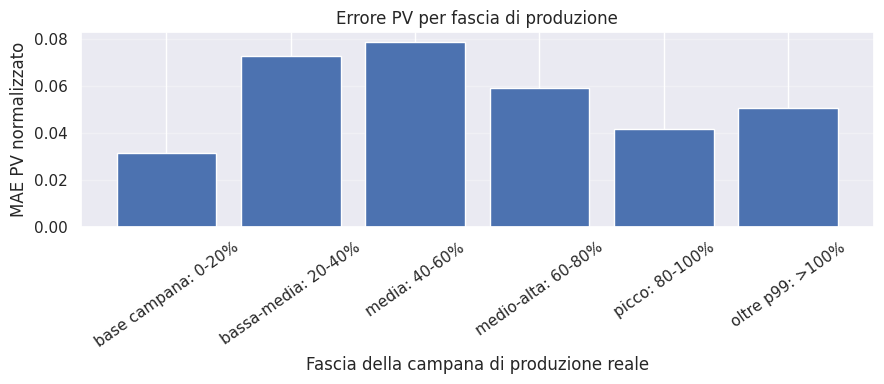


Tabelle salvate in: ../checkpoints/band_metrics


In [4]:

# MAE/RMSE per fasce della campana di produzione energetica
# Richiede che la cella "Inference: collect pred vs actual" sia già stata eseguita.

import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

def _metrics_by_band(pred, true, band_values, edges, labels, title, unit="", min_n=1):
    """
    Calcola MAE, RMSE e bias dentro fasce definite su band_values.

    pred, true      : valori predetti e reali su cui calcolare l'errore
    band_values     : variabile usata per assegnare ogni campione a una fascia
                      es. true_pv_d normalizzato, oppure kWp stimato dell'impianto
    edges, labels   : estremi e nomi delle fasce
    title           : titolo stampato sopra la tabella
    unit            : unità da mostrare nelle colonne metriche
    """
    pred = np.asarray(pred, dtype=float)
    true = np.asarray(true, dtype=float)
    band_values = np.asarray(band_values, dtype=float)

    valid = np.isfinite(pred) & np.isfinite(true) & np.isfinite(band_values)
    pred = pred[valid]
    true = true[valid]
    band_values = band_values[valid]

    idx = np.digitize(band_values, edges[1:-1], right=False)

    rows = []
    for i, label in enumerate(labels):
        m = idx == i
        n = int(m.sum())
        if n < min_n:
            rows.append({
                "fascia": label,
                "n": n,
                "share_%": np.nan,
                f"MAE{unit}": np.nan,
                f"RMSE{unit}": np.nan,
                f"bias{unit}": np.nan,
                "actual_mean": np.nan,
                "pred_mean": np.nan,
            })
            continue

        err = pred[m] - true[m]
        rows.append({
            "fascia": label,
            "n": n,
            "share_%": float(n / len(pred) * 100.0),
            f"MAE{unit}": float(np.mean(np.abs(err))),
            f"RMSE{unit}": float(np.sqrt(np.mean(err ** 2))),
            f"bias{unit}": float(np.mean(err)),
            "actual_mean": float(np.mean(true[m])),
            "pred_mean": float(np.mean(pred[m])),
        })

    df = pd.DataFrame(rows)
    print(f"\n=== {title} ===")
    display(df)

    return df


# ---------------------------------------------------------------------
# 1) Fasce della campana basate sulla produzione PV reale normalizzata
# ---------------------------------------------------------------------
# true_pv_d è già normalizzato rispetto alla scala dell'impianto.
# Quindi 0.8-1.0 significa "campione vicino al picco della campana",
# non "impianto piccolo/grande".
production_edges = np.array([0.0, 0.2, 0.4, 0.6, 0.8, 1.0, np.inf])
production_labels = [
    "base campana: 0-20%",
    "bassa-media: 20-40%",
    "media: 40-60%",
    "medio-alta: 60-80%",
    "picco: 80-100%",
    "oltre p99: >100%",
]

pv_band_norm = _metrics_by_band(
    pred=pred_pv_d,
    true=true_pv_d,
    band_values=true_pv_d,
    edges=production_edges,
    labels=production_labels,
    title="PV normalizzato - MAE/RMSE per fasce della campana di produzione",
    unit="",
)


# ---------------------------------------------------------------------
# 2) Stesse fasce, ma errore riportato in kW stimati
# ---------------------------------------------------------------------
# dataset.pv_scale[p] è il p99 della produzione diurna del plant p.
# Moltiplicando il valore normalizzato per pv_scale otteniamo un'approssimazione in kW.
pv_scale_by_sample = np.asarray(dataset.pv_scale)[plant_id_d.astype(int)]

true_pv_kw_d = true_pv_d * pv_scale_by_sample
pred_pv_kw_d = pred_pv_d * pv_scale_by_sample

pv_band_kw = _metrics_by_band(
    pred=pred_pv_kw_d,
    true=true_pv_kw_d,
    band_values=true_pv_d,  # le fasce restano quelle della campana normalizzata
    edges=production_edges,
    labels=production_labels,
    title="PV stimato [kW] - MAE/RMSE per fasce della campana di produzione",
    unit=" [kW]",
)


# ---------------------------------------------------------------------
# 3) GHI: errore irradiance per fasce di produzione PV
# ---------------------------------------------------------------------
# Utile se vuoi mostrare se gli errori GHI aumentano nelle stesse zone
# della campana energetica.
ghi_by_pv_band = _metrics_by_band(
    pred=pred_ghi_d,
    true=true_ghi_d,
    band_values=true_pv_d,
    edges=production_edges,
    labels=production_labels,
    title="GHI [kW/m²] - MAE/RMSE per fasce della campana PV",
    unit=" [kW/m²]",
)


# ---------------------------------------------------------------------
# 4) Opzionale: fasce per taglia dell'impianto/campana
# ---------------------------------------------------------------------
# Se per "dimensione della campana" il professore intende la taglia
# dell'impianto, qui raggruppiamo i campioni per quartili di kWp stimato.
solar_p99_arr = getattr(dataset, "solar_p99", getattr(dataset, "pvgis_p99", None))
if solar_p99_arr is not None:
    kWp_est = np.asarray(dataset.pv_scale) / np.asarray(solar_p99_arr)
    finite_size = np.isfinite(kWp_est)
    if finite_size.sum() >= 4:
        q = np.nanpercentile(kWp_est[finite_size], [0, 25, 50, 75, 100])
        q = np.unique(q)

        if len(q) >= 3:
            size_edges = q.copy()
            size_edges[-1] = np.inf
            size_edges[0] = -np.inf
            size_labels = [f"Q{i+1}: {q[i]:.1f}-{q[i+1]:.1f} kWp" for i in range(len(q)-1)]

            size_by_sample = kWp_est[plant_id_d.astype(int)]
            pv_by_plant_size_kw = _metrics_by_band(
                pred=pred_pv_kw_d,
                true=true_pv_kw_d,
                band_values=size_by_sample,
                edges=size_edges,
                labels=size_labels,
                title="PV stimato [kW] - MAE/RMSE per taglia stimata dell'impianto",
                unit=" [kW]",
            )
        else:
            print("\nFasce per taglia impianto non calcolate: quartili non distinti.")
    else:
        print("\nFasce per taglia impianto non calcolate: pochi kWp stimati validi.")
else:
    print("\nFasce per taglia impianto non calcolate: dataset.solar_p99/pvgis_p99 non disponibile.")


# ---------------------------------------------------------------------
# 5) Grafico: MAE normalizzato lungo la campana di produzione
# ---------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(9, 4))
plot_df = pv_band_norm.dropna(subset=["MAE"])
ax.bar(plot_df["fascia"], plot_df["MAE"])
ax.set_ylabel("MAE PV normalizzato")
ax.set_xlabel("Fascia della campana di produzione reale")
ax.set_title("Errore PV per fascia di produzione")
ax.tick_params(axis="x", rotation=35)
ax.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


# ---------------------------------------------------------------------
# 6) Salvataggio tabelle
# ---------------------------------------------------------------------
out_dir = Path(CKPT) / "band_metrics"
out_dir.mkdir(parents=True, exist_ok=True)

pv_band_norm.to_csv(out_dir / "pv_metrics_by_production_band_normalized.csv", index=False)
pv_band_kw.to_csv(out_dir / "pv_metrics_by_production_band_kw.csv", index=False)
ghi_by_pv_band.to_csv(out_dir / "ghi_metrics_by_pv_production_band.csv", index=False)

if "pv_by_plant_size_kw" in globals():
    pv_by_plant_size_kw.to_csv(out_dir / "pv_metrics_by_plant_size_kw.csv", index=False)

print(f"\nTabelle salvate in: {out_dir}")


In [5]:
# QS sanity: confronta binning raw (qs_raw) vs shrunk (qs, gia' applicato in cell 1).
# Mostra che shrinkage isola il regime di degrado vero rimuovendo sparsity contamination.
qs_raw_arr = np.asarray(qs_raw.values)
qs_shrunk_arr = np.asarray(qs.values)

qs_raw_flat = np.nan_to_num(qs_raw_arr[plant_id_flat, time_idx_flat], nan=0.0)
qs_shrunk_flat = qs_shrunk_arr[plant_id_flat, time_idx_flat]

qs_raw_d = qs_raw_flat[day_mask]
qs_shrunk_d = qs_shrunk_flat[day_mask]

print('=== QS BINNING: raw vs shrunk ===')

print('\n--- QS_RAW (compute_qs originale) ---')
_ = _metrics_by_qs_bin(pred_pv_d, true_pv_d, qs_raw_d)

print('\n--- QS_SHRUNK (calcolo principale) ---')
_ = _metrics_by_qs_bin(pred_pv_d, true_pv_d, qs_shrunk_d)

print(
    f"\nShrinkage parameters: prior={qs.attrs['qs_prior']:.3f}, "
    f"n0={qs.attrs['shrinkage_n0']}, scale={qs.attrs['shrinkage_scale']}"
)


=== QS BINNING: raw vs shrunk ===

--- QS_RAW (compute_qs originale) ---

=== PV ERROR BY QS BIN (daytime, n=3,061,186) ===
  low      (<p5=0.000): n=0
  mid-low  (0.000-0.469): n=  765,297  QS_mean=0.025  MAE=0.0494  RMSE=0.0934  bias=+0.0011  actual_mean=0.263  pred_mean=0.264
  medium   (0.469-0.774): n=1,530,592  QS_mean=0.715  MAE=0.0515  RMSE=0.0843  bias=+0.0059  actual_mean=0.364  pred_mean=0.370
  high     (0.774-0.807): n=  612,237  QS_mean=0.789  MAE=0.0464  RMSE=0.0739  bias=+0.0061  actual_mean=0.470  pred_mean=0.476
  very high (>p95=0.807): n=  153,060  QS_mean=0.817  MAE=0.0482  RMSE=0.0714  bias=+0.0076  actual_mean=0.487  pred_mean=0.495
  QS_mean vs MAE correlation across bins: -0.264 (expected negative)
  Interpretation: QS is aligned with predictive reliability (higher QS -> lower MAE).

--- QS_SHRUNK (calcolo principale) ---

=== PV ERROR BY QS BIN (daytime, n=3,061,186) ===
  low      (<p5=0.713): n=  153,060  QS_mean=0.635  MAE=0.0658  RMSE=0.1201  bias=+0.0076 

=== TIME SERIES METRICS ===
  Plant    0 PV:  r=0.983  MAE=0.0330  RMSE=0.0692  bias=-0.0001  amp=0.96
  Plant    0 GHI: r=0.993  MAE=0.0146  bias=-0.0058
  Plant  500 PV:  r=0.983  MAE=0.0314  RMSE=0.0645  bias=-0.0002  amp=0.99
  Plant  500 GHI: r=0.983  MAE=0.0193  bias=-0.0002
  Plant 1115 PV:  r=0.981  MAE=0.0307  RMSE=0.0604  bias=+0.0023  amp=1.01
  Plant 1115 GHI: r=0.982  MAE=0.0202  bias=-0.0055


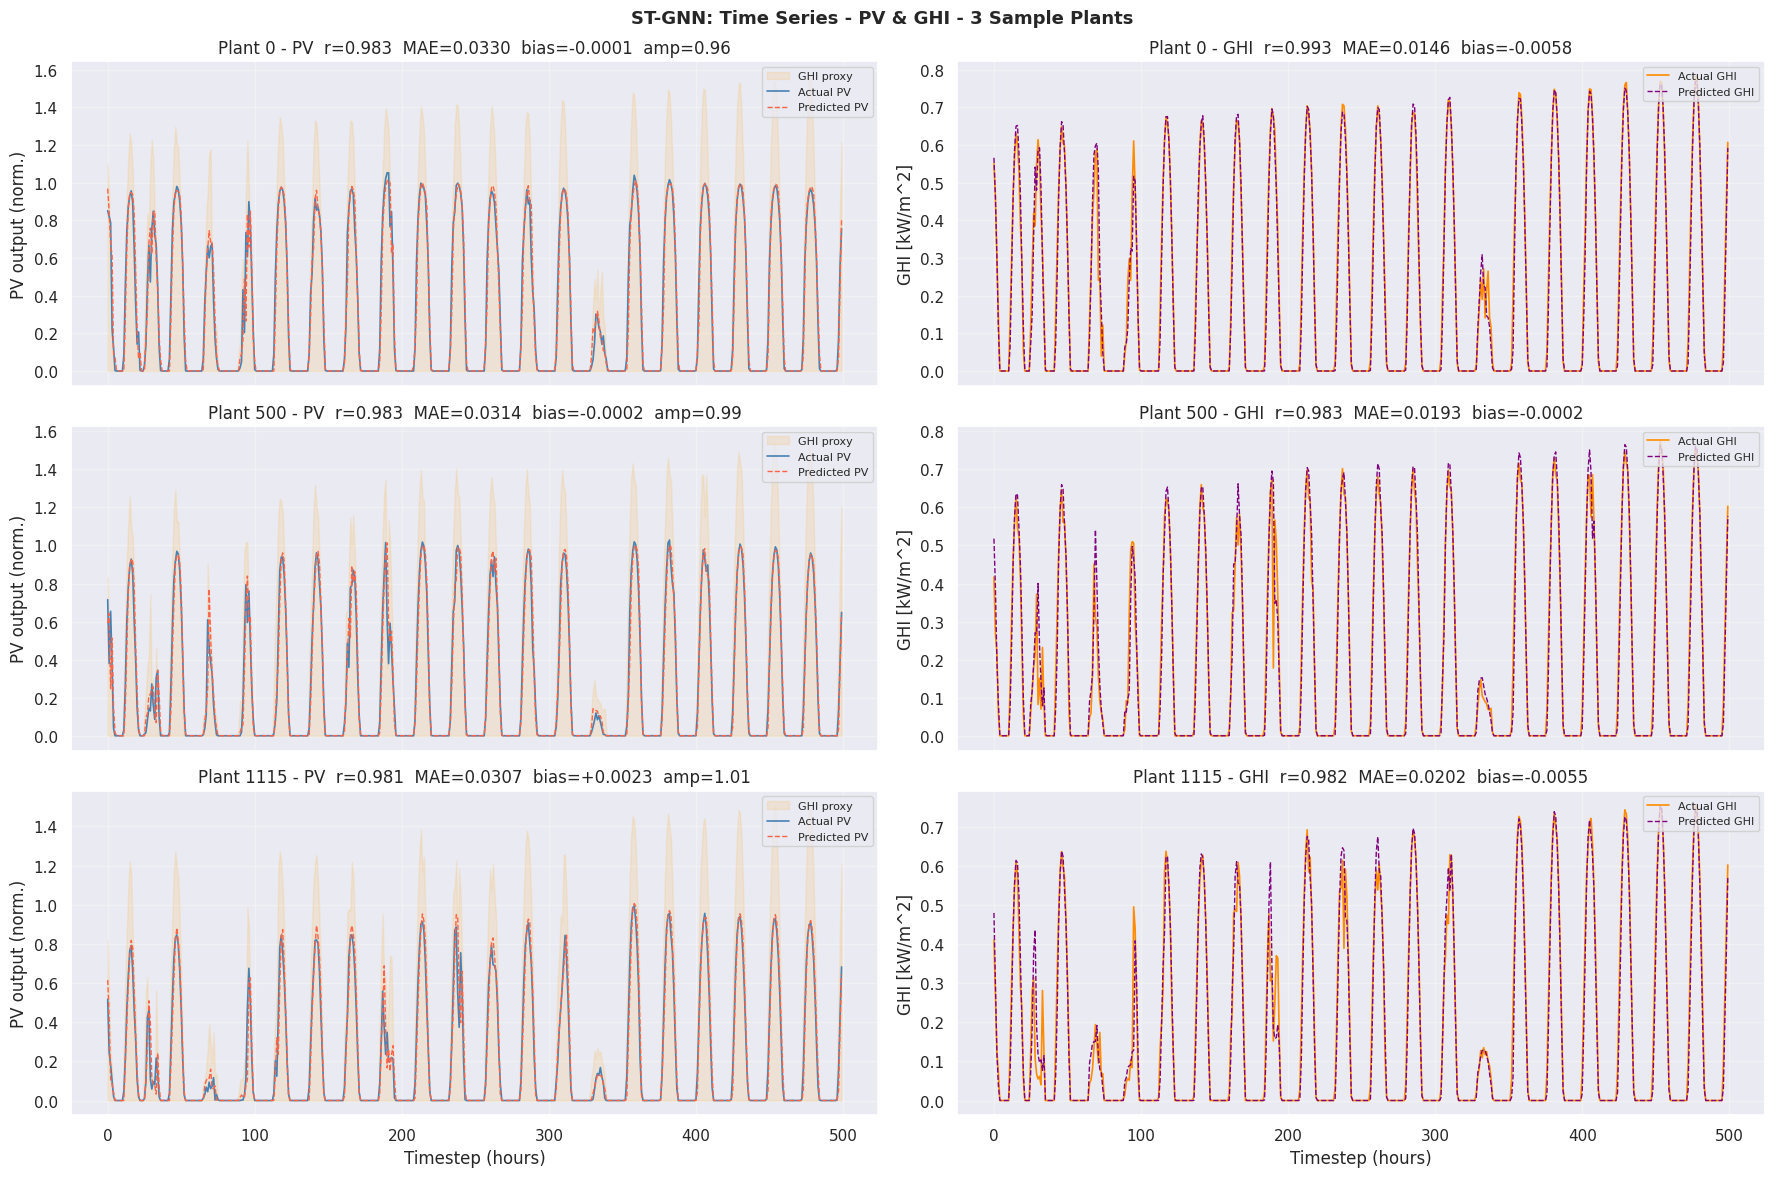

In [6]:
# Time series: 3 sample plants (spread across fleet)
T_SHOW = 500
sample_plant_ids = [0, 500, 1115]

if 'pv_calibration' not in globals():
    pv_calibration = {'enabled': False, 'slope': 1.0, 'intercept': 0.0, 'daytime_ghi_threshold': 0.01}

calib_enabled   = bool(pv_calibration.get('enabled', False))
calib_slope     = float(pv_calibration.get('slope', 1.0))
calib_intercept = float(pv_calibration.get('intercept', 0.0))

seq_pred_pv  = {p: [] for p in sample_plant_ids}
seq_true_pv  = {p: [] for p in sample_plant_ids}
seq_pred_ghi = {p: [] for p in sample_plant_ids}
seq_true_ghi = {p: [] for p in sample_plant_ids}

with torch.no_grad():
    for i, (x, y_ghi, y_pv, eta, ghi_cs) in enumerate(loader):
        if i * loader.batch_size >= T_SHOW:
            break
        pg, pp = model(x.to(DEVICE), ei, ew, ghi_cs.to(DEVICE))
        pp_np = pp.cpu().numpy()
        pg_np = pg.cpu().numpy()
        if calib_enabled:
            pp_np = calib_slope * pp_np + calib_intercept
        pp_np = np.clip(pp_np, 0.0, None)
        for p in sample_plant_ids:
            seq_pred_pv[p].append(pp_np[:, p])
            seq_true_pv[p].append(y_pv[:, p].numpy())
            seq_pred_ghi[p].append(pg_np[:, p])
            seq_true_ghi[p].append(y_ghi[:, p].numpy())

n_plants = len(sample_plant_ids)
fig, axes = plt.subplots(n_plants, 2, figsize=(18, 4 * n_plants), sharex=True)

print("=== TIME SERIES METRICS ===")
for row, p in enumerate(sample_plant_ids):
    t_pv  = np.concatenate(seq_true_pv[p])[:T_SHOW]
    p_pv  = np.concatenate(seq_pred_pv[p])[:T_SHOW]
    t_ghi = np.concatenate(seq_true_ghi[p])[:T_SHOW]
    p_ghi = np.concatenate(seq_pred_ghi[p])[:T_SHOW]
    steps = np.arange(len(t_pv))

    # PV metrics
    corr_pv   = float(np.corrcoef(t_pv, p_pv)[0, 1]) if t_pv.std() > 0 else float('nan')
    mae_pv    = float(np.mean(np.abs(t_pv - p_pv)))
    rmse_pv   = float(np.sqrt(np.mean((t_pv - p_pv) ** 2)))
    bias_pv   = float(np.mean(p_pv - t_pv))
    amp_ratio = float(p_pv.max() / t_pv.max()) if t_pv.max() > 0 else float('nan')

    # GHI metrics
    corr_ghi = float(np.corrcoef(t_ghi, p_ghi)[0, 1]) if t_ghi.std() > 0 else float('nan')
    mae_ghi  = float(np.mean(np.abs(t_ghi - p_ghi)))
    bias_ghi = float(np.mean(p_ghi - t_ghi))

    # --- PV subplot ---
    ax_pv = axes[row, 0]
    ax_pv.fill_between(steps, 0, t_ghi * 2, alpha=0.12, color='orange', label='GHI proxy')
    ax_pv.plot(steps, t_pv, color='steelblue', linewidth=1.2, label='Actual PV')
    ax_pv.plot(steps, p_pv, color='tomato',    linewidth=1.0, linestyle='--', label='Predicted PV')
    ax_pv.set_ylabel('PV output (norm.)')
    ax_pv.set_title(f'Plant {p} - PV  r={corr_pv:.3f}  MAE={mae_pv:.4f}  bias={bias_pv:+.4f}  amp={amp_ratio:.2f}')
    ax_pv.legend(loc='upper right', fontsize=8)
    ax_pv.grid(True, alpha=0.3)

    # --- GHI subplot ---
    ax_ghi = axes[row, 1]
    ax_ghi.plot(steps, t_ghi, color='darkorange', linewidth=1.2, label='Actual GHI')
    ax_ghi.plot(steps, p_ghi, color='purple',     linewidth=1.0, linestyle='--', label='Predicted GHI')
    ax_ghi.set_ylabel('GHI [kW/m^2]')
    ax_ghi.set_title(f'Plant {p} - GHI  r={corr_ghi:.3f}  MAE={mae_ghi:.4f}  bias={bias_ghi:+.4f}')
    ax_ghi.legend(loc='upper right', fontsize=8)
    ax_ghi.grid(True, alpha=0.3)

    print(f"  Plant {p:>4} PV:  r={corr_pv:.3f}  MAE={mae_pv:.4f}  RMSE={rmse_pv:.4f}  bias={bias_pv:+.4f}  amp={amp_ratio:.2f}")
    print(f"  Plant {p:>4} GHI: r={corr_ghi:.3f}  MAE={mae_ghi:.4f}  bias={bias_ghi:+.4f}")

for ax in axes[-1, :]:
    ax.set_xlabel('Timestep (hours)')

plt.suptitle('ST-GNN: Time Series - PV & GHI - 3 Sample Plants', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


## Quality Score

In [7]:
# Diagnostic: timesteps per month (verifica gap nei CSV Sentinel)
import pandas as pd
times = pd.DatetimeIndex(ds['time'].values)
monthly_counts = pd.Series(1, index=times).resample('ME').count()
print("Timesteps per month (0 = mese assente nei CSV Sentinel):")
for mo, cnt in monthly_counts.items():
    bar = '#' * (cnt // 20)
    expected = mo.days_in_month * 24
    pct = cnt / expected * 100
    print(f"  {mo.strftime('%b %Y')}: {cnt:>4}h / {expected}h ({pct:4.0f}%)  {bar}")

Timesteps per month (0 = mese assente nei CSV Sentinel):
  Mar 2019:  694h / 744h (  93%)  ##################################
  Apr 2019:  683h / 720h (  95%)  ##################################
  May 2019:  694h / 744h (  93%)  ##################################
  Jun 2019:    0h / 720h (   0%)  
  Jul 2019:  744h / 744h ( 100%)  #####################################
  Aug 2019:    0h / 744h (   0%)  
  Sep 2019:  720h / 720h ( 100%)  ####################################
  Oct 2019:  744h / 744h ( 100%)  #####################################
  Nov 2019:  720h / 720h ( 100%)  ####################################
  Dec 2019:  744h / 744h ( 100%)  #####################################


=== QUALITY SCORE REPORT ===
  Shape: 1116 plants x 5743 timesteps
  Valid QS values: 6,409,188 / 6,409,188 (100.0%)
  Daytime valid:   2,754,821 (43.0%)

  GLOBAL (all valid):
    mean=0.758  median=0.783  std=0.091
    p10=0.745  p25=0.770  p75=0.783  p90=0.783

  DAYTIME ONLY:
    mean=0.764  median=0.772  std=0.041

  PER-PLANT (daytime mean, 0 plants no daytime data):
    min=0.547  max=0.797  mean=0.764  std=0.029
    plants QS>0.7: 1070  QS 0.5-0.7: 46  QS<0.5: 0  no data: 0

  MONTHLY fleet mean (daytime only):
    Mar: 0.782  #######################
    Apr: 0.770  #######################
    May: 0.763  ######################
    Jun: NaN  (no data in Sentinel CSVs)
    Jul: 0.760  ######################
    Aug: NaN  (no data in Sentinel CSVs)
    Sep: 0.752  ######################
    Oct: 0.750  ######################
    Nov: 0.765  ######################
    Dec: 0.773  #######################


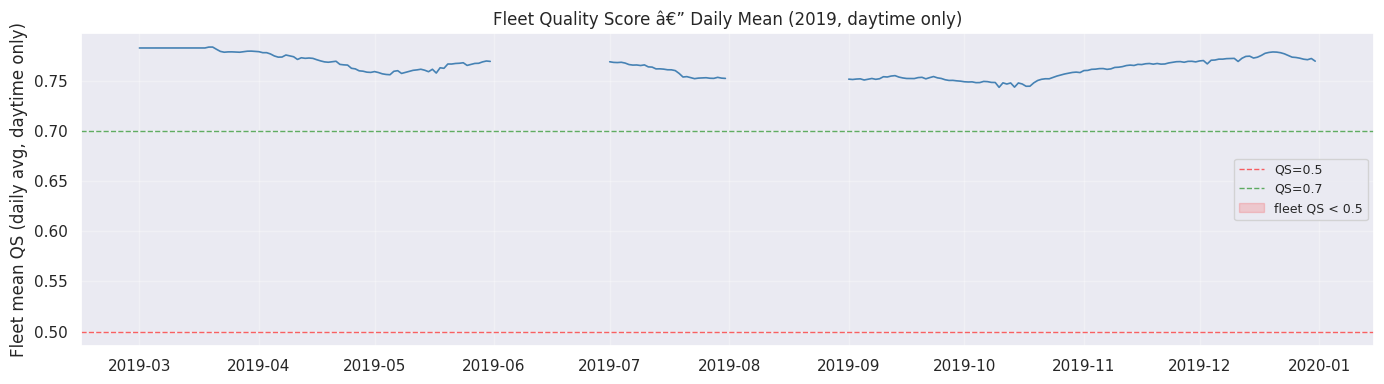

In [8]:
import pandas as pd
import warnings

qs_arr = qs.values                          # (N, T)
lats   = ds['lat'].values
lons   = ds['lon'].values
times  = pd.DatetimeIndex(ds['time'].values)
N, T   = qs_arr.shape

# Per-plant mean QS (daytime only: solar_irradiance_poa > 50 W/m^2)
poa    = ds['solar_irradiance_poa'].values  # (N, T)  W/m^2
day    = poa > 50.0
qs_day = np.where(day, qs_arr, np.nan)

with warnings.catch_warnings():
    warnings.simplefilter("ignore", RuntimeWarning)
    qs_plant_mean = np.nanmean(qs_day, axis=1)  # (N,) â€” NaN if plant has no daytime QS

# Fleet daily mean QS â€” daytime only (excludes spurious nighttime readings)
with warnings.catch_warnings():
    warnings.simplefilter("ignore", RuntimeWarning)
    qs_fleet_hourly = pd.Series(np.nanmean(qs_day, axis=0), index=times)
qs_fleet_daily  = qs_fleet_hourly.resample('1D').mean()
qs_monthly = qs_fleet_hourly.resample('ME').mean()

# --- Text report ---
qs_valid     = qs_arr[~np.isnan(qs_arr)]
qs_day_valid = qs_day[~np.isnan(qs_day)]
pm_valid     = qs_plant_mean[~np.isnan(qs_plant_mean)]
n_nan_plants = int(np.isnan(qs_plant_mean).sum())

print("=== QUALITY SCORE REPORT ===")
print(f"  Shape: {N} plants x {T} timesteps")
print(f"  Valid QS values: {len(qs_valid):,} / {qs_arr.size:,} ({len(qs_valid)/qs_arr.size*100:.1f}%)")
print(f"  Daytime valid:   {len(qs_day_valid):,} ({len(qs_day_valid)/qs_arr.size*100:.1f}%)")
print(f"\n  GLOBAL (all valid):")
print(f"    mean={np.nanmean(qs_valid):.3f}  median={np.nanmedian(qs_valid):.3f}  std={np.nanstd(qs_valid):.3f}")
print(f"    p10={np.nanpercentile(qs_valid,10):.3f}  p25={np.nanpercentile(qs_valid,25):.3f}"
      f"  p75={np.nanpercentile(qs_valid,75):.3f}  p90={np.nanpercentile(qs_valid,90):.3f}")
print(f"\n  DAYTIME ONLY:")
print(f"    mean={np.nanmean(qs_day_valid):.3f}  median={np.nanmedian(qs_day_valid):.3f}  std={np.nanstd(qs_day_valid):.3f}")
print(f"\n  PER-PLANT (daytime mean, {n_nan_plants} plants no daytime data):")
if len(pm_valid) > 0:
    print(f"    min={pm_valid.min():.3f}  max={pm_valid.max():.3f}"
          f"  mean={pm_valid.mean():.3f}  std={pm_valid.std():.3f}")
    print(f"    plants QS>0.7: {(pm_valid>0.7).sum()}"
          f"  QS 0.5-0.7: {((pm_valid>=0.5)&(pm_valid<=0.7)).sum()}"
          f"  QS<0.5: {(pm_valid<0.5).sum()}"
          f"  no data: {n_nan_plants}")
print(f"\n  MONTHLY fleet mean (daytime only):")
for mo, val in qs_monthly.items():
    if np.isnan(val):
        print(f"    {mo.strftime('%b'):>3}: NaN  (no data in Sentinel CSVs)")
    else:
        bar = '#' * int(val * 30)
        print(f"    {mo.strftime('%b'):>3}: {val:.3f}  {bar}")

# --- Fleet QS daily time series ---
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(qs_fleet_daily.index, qs_fleet_daily.values, linewidth=1.2, color='steelblue')
ax.axhline(0.5, color='red',    linestyle='--', alpha=0.6, linewidth=1, label='QS=0.5')
ax.axhline(0.7, color='green',  linestyle='--', alpha=0.6, linewidth=1, label='QS=0.7')
ax.fill_between(qs_fleet_daily.index, qs_fleet_daily.values, 0,
                where=qs_fleet_daily.values < 0.5, alpha=0.15, color='red', label='fleet QS < 0.5')
ax.set_ylabel('Fleet mean QS (daily avg, daytime only)')
ax.set_title('Fleet Quality Score â€” Daily Mean (2019, daytime only)')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

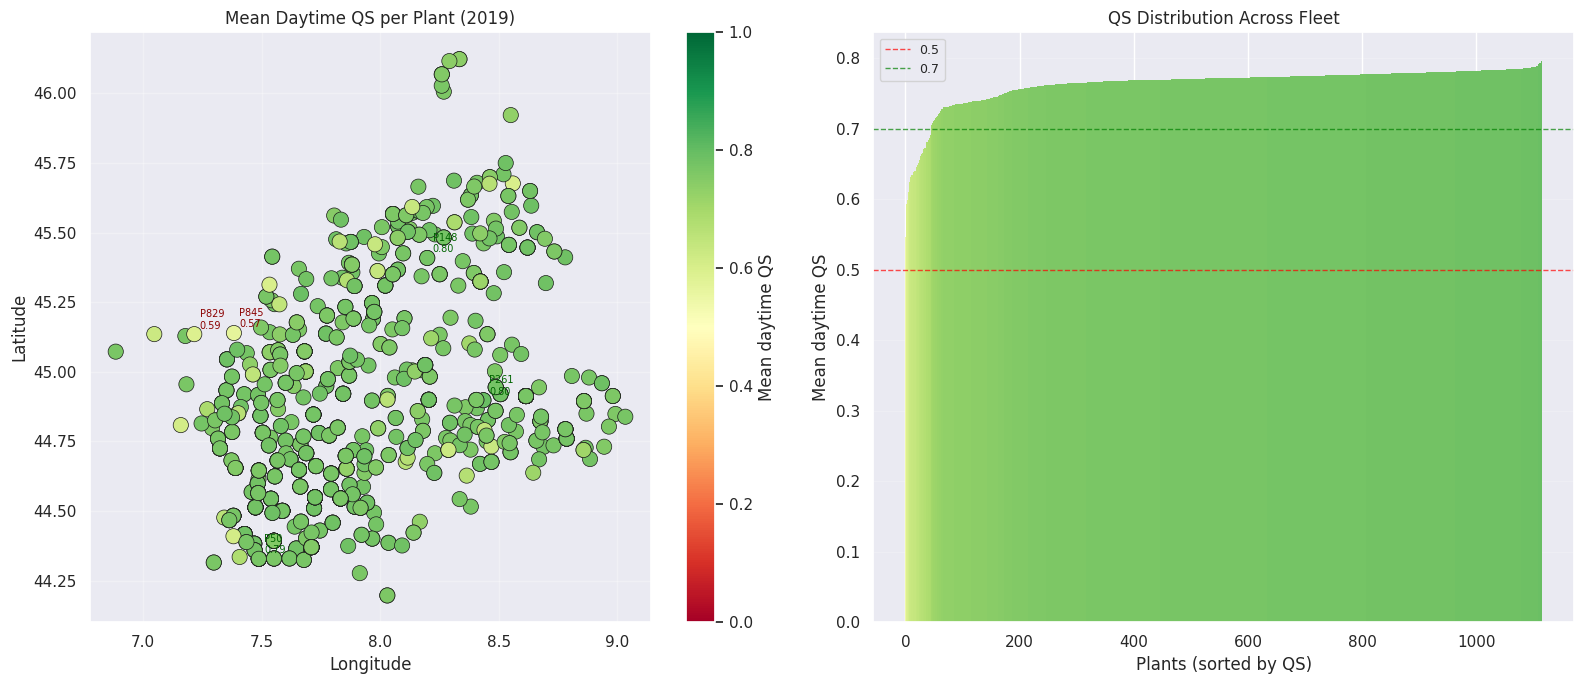

=== SPATIAL QS ===
  Top-5 plants (highest QS):
    1. Plant  148: QS=0.797  lat=45.409  lon=8.199
    2. Plant  261: QS=0.796  lat=44.898  lon=8.436
    3. Plant   50: QS=0.794  lat=44.329  lon=7.488
    4. Plant  638: QS=0.793  lat=44.545  lon=7.833
    5. Plant  765: QS=0.793  lat=44.393  lon=7.551
  Bottom-5 plants (lowest QS):
    1. Plant  946: QS=0.547  lat=nan  lon=nan
    2. Plant  845: QS=0.569  lat=45.139  lon=7.382
    3. Plant  829: QS=0.594  lat=45.135  lon=7.215
    4. Plant  851: QS=0.598  lat=45.313  lon=7.533
    5. Plant   47: QS=0.599  lat=45.676  lon=8.560


In [9]:
# Spatial map: plants colored by mean daytime QS
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Left: QS map (exclude NaN plants from colormap)
ax = axes[0]
valid_mask = ~np.isnan(qs_plant_mean)
sc = ax.scatter(lons[valid_mask], lats[valid_mask],
                c=qs_plant_mean[valid_mask], s=120,
                cmap='RdYlGn', vmin=0.0, vmax=1.0,
                edgecolors='k', linewidth=0.5, zorder=3)
if (~valid_mask).any():
    ax.scatter(lons[~valid_mask], lats[~valid_mask],
               s=120, c='grey', marker='x', linewidth=1.5, zorder=4, label='no data')
    ax.legend(fontsize=8)
plt.colorbar(sc, ax=ax, label='Mean daytime QS')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('Mean Daytime QS per Plant (2019)')
ax.grid(True, alpha=0.3)

# Annotate top-3 and bottom-3 â€” exclude NaN
valid_idx = np.where(valid_mask)[0]
sorted_valid = valid_idx[np.argsort(qs_plant_mean[valid_idx])]
top3    = sorted_valid[-3:][::-1]
bottom3 = sorted_valid[:3]
for idx in top3:
    ax.annotate(f'P{idx}\n{qs_plant_mean[idx]:.2f}',
                (lons[idx], lats[idx]), fontsize=7, color='darkgreen',
                xytext=(4, 4), textcoords='offset points')
for idx in bottom3:
    ax.annotate(f'P{idx}\n{qs_plant_mean[idx]:.2f}',
                (lons[idx], lats[idx]), fontsize=7, color='darkred',
                xytext=(4, 4), textcoords='offset points')

# Right: QS distribution per plant (sorted bar)
ax2 = axes[1]
order = np.argsort(np.where(valid_mask, qs_plant_mean, -1))
colors = plt.cm.RdYlGn(np.clip(qs_plant_mean[order], 0, 1))
ax2.bar(range(N), np.where(valid_mask[order], qs_plant_mean[order], 0),
        color=colors, edgecolor='none', width=1.0)
ax2.axhline(0.5, color='red',   linestyle='--', linewidth=1, alpha=0.7, label='0.5')
ax2.axhline(0.7, color='green', linestyle='--', linewidth=1, alpha=0.7, label='0.7')
ax2.set_xlabel('Plants (sorted by QS)')
ax2.set_ylabel('Mean daytime QS')
ax2.set_title('QS Distribution Across Fleet')
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.2, axis='y')

plt.tight_layout()
plt.show()

# Text: top/bottom 5 (NaN excluded)
print("=== SPATIAL QS ===")
print("  Top-5 plants (highest QS):")
for i, idx in enumerate(sorted_valid[-5:][::-1]):
    print(f"    {i+1}. Plant {idx:>4}: QS={qs_plant_mean[idx]:.3f}  lat={lats[idx]:.3f}  lon={lons[idx]:.3f}")
print("  Bottom-5 plants (lowest QS):")
for i, idx in enumerate(sorted_valid[:5]):
    print(f"    {i+1}. Plant {idx:>4}: QS={qs_plant_mean[idx]:.3f}  lat={lats[idx]:.3f}  lon={lons[idx]:.3f}")
if n_nan_plants > 0:
    nan_idx = np.where(~valid_mask)[0]
    print(f"  Plants with no daytime data ({n_nan_plants}): {list(nan_idx)}")

In [10]:
# Plant size estimates (kWp proxy) and per-plant PR
pv_scale_arr = dataset.pv_scale  # (N,) p99 ENERGIA daytime [kW]

# New pipeline uses irradiance-based reference (solar_p99).
# Keep fallback to legacy alias for old checkpoints/notebooks.
solar_p99_arr = getattr(dataset, "solar_p99", getattr(dataset, "pvgis_p99"))
eta_adj_arr = dataset.eta_adjusted  # (N,) per-plant eta proxy [dimensionless]

# kWp proxy estimate: p99(ENERGIA_day) / p99(solar_irradiance_poa_day[kW/m^2])
kWp_est = pv_scale_arr / solar_p99_arr  # (N,)

# PR proxy = eta_adjusted (data-driven ratio used in physics loss)
pr_actual = eta_adj_arr

print("=== PER-PLANT SIZE AND PERFORMANCE RATIO ===")
print(f"  {'Plant':>5}  {'kWp_est':>8}  {'PR':>6}  {'pv_scale':>9}  {'solar_p99':>9}  {'eta_adj':>8}")
print(f"  {'-'*5}  {'-'*8}  {'-'*6}  {'-'*9}  {'-'*9}  {'-'*8}")
for p in range(len(kWp_est)):
    print(f"  {p:>5}  {kWp_est[p]:>8.1f}  {pr_actual[p]:>6.3f}  {pv_scale_arr[p]:>9.1f}  {solar_p99_arr[p]:>9.3f}  {eta_adj_arr[p]:>8.3f}")

print(f"\n  FLEET SUMMARY:")
print(f"  kWp  - min={kWp_est.min():.1f}  max={kWp_est.max():.1f}  mean={kWp_est.mean():.1f}  median={np.median(kWp_est):.1f}")
print(f"  PR   - min={pr_actual.min():.3f}  max={pr_actual.max():.3f}  mean={pr_actual.mean():.3f}  std={pr_actual.std():.3f}")
print(f"  Note: kWp_est = p99(ENERGIA_day) / p99(solar_irradiance_poa_day)")
print(f"        PR proxy = eta_adjusted (irradiance-based, no pvgis_ref dependency)")


=== PER-PLANT SIZE AND PERFORMANCE RATIO ===
  Plant   kWp_est      PR   pv_scale  solar_p99   eta_adj
  -----  --------  ------  ---------  ---------  --------
      0     874.9   0.980      814.1      0.931     0.980
      1      71.0   0.897       66.0      0.930     0.897
      2     191.7   0.914      179.0      0.934     0.914
      3      71.4   0.833       66.0      0.925     0.833
      4      91.7   0.931       84.7      0.924     0.931
      5      67.6   0.942       63.0      0.932     0.942
      6     891.6   0.918      826.1      0.927     0.918
      7      81.2   0.922       76.2      0.939     0.922
      8      17.4   0.959       16.0      0.922     0.959
      9      64.6   0.835       60.0      0.929     0.835
     10      48.8   0.939       45.0      0.923     0.939
     11     883.9   0.910      827.4      0.936     0.910
     12     210.7   0.881      194.0      0.921     0.881
     13     521.8   0.951      491.9      0.943     0.951
     14    2371.6   0.868  